✅ Accuracy: 1.0

Confusion Matrix:
 [[3 0]
 [0 2]]

Classification Report:
               precision    recall  f1-score   support

           0       1.00      1.00      1.00         3
           1       1.00      1.00      1.00         2

    accuracy                           1.00         5
   macro avg       1.00      1.00      1.00         5
weighted avg       1.00      1.00      1.00         5



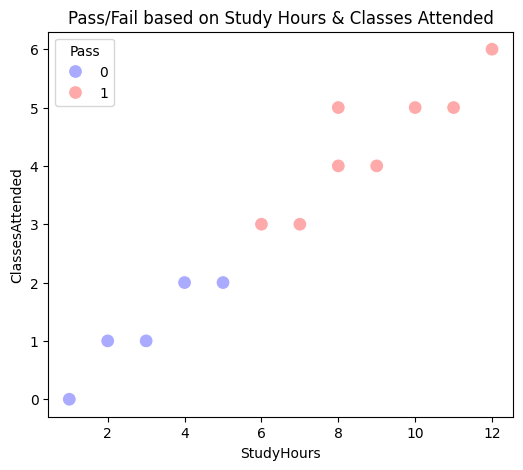

c:\Users\soura\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LogisticRegression was fitted with feature names
  warnings.warn(
c:\Users\soura\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LogisticRegression was fitted with feature names
  warnings.warn(
c:\Users\soura\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LogisticRegression was fitted with feature names
  warnings.warn(
c:\Users\soura\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LogisticRegression was fitted with feature names
  warnings.warn(
c:\Users\soura\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\utils\valid

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, accuracy_score, classification_report
import tkinter as tk
from tkinter import messagebox

# ---------------- 1. DATASET ----------------
data={
    'StudyHours': [2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 1, 3, 4, 8],
    'ClassesAttended': [1, 1, 2, 2, 3, 3, 4, 4, 5, 5, 6, 0, 1, 2, 5],
    'Pass': [0, 0, 0, 0, 1, 1, 1, 1, 1, 1, 1, 0, 0, 0, 1]
}
df = pd.DataFrame(data)

# ---------------- 2. PREPROCESSING ----------------
X = df[['StudyHours', 'ClassesAttended']]
y = df['Pass']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

# ---------------- 3. MODEL TRAINING ----------------
model = LogisticRegression()
model.fit(X_train, y_train)

# ---------------- 4. EVALUATION ----------------
y_pred = model.predict(X_test)
print("✅ Accuracy:", accuracy_score(y_test, y_pred))
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))

# ---------------- 5. VISUALIZATION ----------------
plt.figure(figsize=(6,5))
sns.scatterplot(x='StudyHours', y='ClassesAttended', hue='Pass', data=df, palette='bwr', s=100)
plt.title("Pass/Fail based on Study Hours & Classes Attended")
plt.show()

# ---------------- 6. TKINTER UI ----------------
def predict_result():
    try:
        study_hours = float(entry_hours.get())
        classes_attended = float(entry_classes.get())

        prediction = model.predict([[study_hours, classes_attended]])[0]
        result = "✅ PASS" if prediction == 1 else "❌ FAIL"
        messagebox.showinfo("Prediction", f"Result: {result}")
    except:
        messagebox.showerror("Error", "Please enter valid numbers.")

# Create Window
root = tk.Tk()
root.title("🎓 Student Pass/Fail Prediction")
root.geometry("350x250")
root.config(bg="lightyellow")

tk.Label(root, text="Enter Student Details", font=("Arial", 16, "bold"), bg="lightyellow").pack(pady=10)

tk.Label(root, text="Study Hours:", bg="lightyellow").pack()
entry_hours = tk.Entry(root)
entry_hours.pack()

tk.Label(root, text="Classes Attended:", bg="lightyellow").pack()
entry_classes = tk.Entry(root)
entry_classes.pack()

tk.Button(root, text="Predict Result", command=predict_result, font=("Arial", 12), bg="green", fg="white").pack(pady=20)

root.mainloop()